In [21]:
import time
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
def O1(n):
    return 9999 * 8888

def On(n):
    s = 0
    for i in range(n):
        s += i
    return s

def On2(n):
    s = 0
    for i in range(n):
        for j in range(n):
            s += 1
    return s

def Ologn(n):
    count = 0
    while n > 1:
        n //= 2
        count += 1
    return count


In [23]:
def avg_time(func, n, repeat=5):
    total = 0
    for _ in range(repeat):
        start = time.perf_counter()
        func(n)
        total += time.perf_counter() - start
    return total / repeat

In [24]:
sizes = [10, 100, 500, 1000]

functions = {
    "O(1)": O1,
    "O(n)": On,
    "O(n^2)": On2,
    "O(log n)": Ologn
}

results = {"n": sizes}

In [25]:
for name, func in functions.items():
    results[name] = [avg_time(func, n) for n in sizes]


In [26]:
df = pd.DataFrame(results)
print("\nExecution Time Table:\n")
print(df)


Execution Time Table:

      n          O(1)      O(n)    O(n^2)  O(log n)
0    10  1.060031e-06  0.000002  0.000012  0.000003
1   100  4.399568e-07  0.000011  0.001092  0.000002
2   500  5.400274e-07  0.000067  0.049298  0.000002
3  1000  3.400259e-07  0.000149  0.128255  0.000006


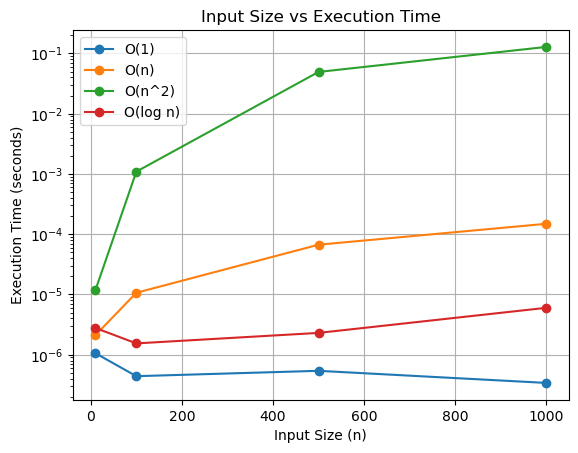

In [27]:
for col in df.columns[1:]:
    plt.plot(df["n"], df[col], marker="o", label=col)

plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Input Size vs Execution Time")
plt.legend()
plt.grid(True)
plt.yscale("log")
plt.show()